# Sprint 1 - Data Exploration & Parsing (SEntFiN v1.1)

**Tujuan:** memahami & memvalidasi dataset, lalu mengubahnya ke *long-format* `(s_no, title, entity, sentiment)` yang siap dipakai untuk **NER** (entity = keys) dan **ABSA** (sentiment = values).

**Output Sprint ini:** `data/processed/sentfin_long.csv`

> Tidak ada modelling di sini. Ini fondasi. Kalau parsing/asumsi di sini salah, semua sprint berikutnya ikut rusak.

In [1]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 100)

PROJECT_ROOT = Path('..').resolve()
DATA_RAW       = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

CSV_PATH = DATA_RAW / 'SEntFiN-v1.1.csv'
print('Reading:', CSV_PATH)
print('Exists  :', CSV_PATH.exists())

Reading: D:\Text Mining Projects\Financial-News-Miner\data\raw\SEntFiN-v1.1.csv
Exists  : True


## 1. Load & sanity check

Kita rename kolom ke `snake_case` supaya enak diakses (`df.s_no` lebih aman daripada `df['S No.']`).

In [2]:
df = pd.read_csv(CSV_PATH, encoding='utf-8')
df.columns = ['s_no', 'title', 'decisions', 'words']  # 'words' = word-count, BUKAN entitas

print('Shape :', df.shape)
print('Dtypes:')
print(df.dtypes)
print('\nNull per kolom:')
print(df.isna().sum())
print('\nDuplikat title penuh:', df['title'].duplicated().sum())
df.head()

Shape : (10753, 4)
Dtypes:
s_no         int64
title          str
decisions      str
words        int64
dtype: object

Null per kolom:
s_no         0
title        0
decisions    0
words        0
dtype: int64

Duplikat title penuh: 67


,s_no,title,decisions,words
0,1,SpiceJet to issue 6.4 crore warrants to promoters,"{""SpiceJet"": ""neutral""}",8
1,2,MMTC Q2 net loss at Rs 10.4 crore,"{""MMTC"": ""neutral""}",8
2,3,"Mid-cap funds can deliver more, stay put: Experts","{""Mid-cap funds"": ""positive""}",8
3,4,Mid caps now turn into market darlings,"{""Mid caps"": ""positive""}",7
4,5,"Market seeing patience, if not conviction: Prakash Diwan","{""Market"": ""neutral""}",8


### Catatan: kolom `words`
Klaim awal kita: `words` = daftar entitas. **Salah.** `words` adalah *jumlah kata* di `title`. Mari verifikasi dengan menghitung token kasar (split spasi) dan membandingkannya.

In [3]:
df['title_wordcount'] = df['title'].str.split().str.len()
agree = (df['title_wordcount'] == df['words']).mean()
print(f"Proporsi baris di mana words == jumlah kata title (split spasi): {agree:.1%}")
print('Korelasi words vs title_wordcount:', df['words'].corr(df['title_wordcount']).round(3))
# Kalau tinggi -> 'words' memang word-count -> kolom ini tidak berguna untuk kita.
df[['title','words','title_wordcount']].head()

Proporsi baris di mana words == jumlah kata title (split spasi): 99.2%
Korelasi words vs title_wordcount: 0.999


,title,words,title_wordcount
0,SpiceJet to issue 6.4 crore warrants to promoters,8,8
1,MMTC Q2 net loss at Rs 10.4 crore,8,8
2,"Mid-cap funds can deliver more, stay put: Experts",8,8
3,Mid caps now turn into market darlings,7,7
4,"Market seeing patience, if not conviction: Prakash Diwan",8,8


## 2. Parse kolom `decisions` (JSON)

`decisions` adalah string JSON `{"entity": "sentiment", ...}`. pandas sudah meng-*unescape* quote ganda CSV, jadi `json.loads` langsung jalan. Kita hitung berapa yang **gagal parse** - target idealnya 0.

In [4]:
def try_parse(s):
    try:
        d = json.loads(s)
        return d if isinstance(d, dict) else None
    except Exception:
        return None

df['parsed'] = df['decisions'].apply(try_parse)
n_fail = df['parsed'].isna().sum()
print(f'Gagal parse: {n_fail} dari {len(df)} baris')

if n_fail:
    print('\nContoh yang gagal:')
    display(df[df['parsed'].isna()][['s_no','title','decisions']].head(10))
else:
    print('Semua baris ter-parse sebagai dict. OK')

# Validasi nilai sentimen: harus dari {positive, negative, neutral}
all_sents = [s for d in df['parsed'].dropna() for s in d.values()]
print('\nNilai sentimen unik:', sorted(set(all_sents)))

Gagal parse: 0 dari 10753 baris
Semua baris ter-parse sebagai dict. OK

Nilai sentimen unik: ['negative', 'neutral', 'positive']


## 3. Explode ke long-format

Satu headline bisa punya banyak entitas. Kita ubah ke bentuk *long* (1 baris = 1 pasangan headline-entity). Ini bentuk natural untuk ABSA dan memudahkan semua agregasi di bawah.

Analog: ini operasi *unnest* / normalisasi dari relasi 1-ke-banyak.

In [5]:
records = []
for r in df.itertuples(index=False):
    if not r.parsed:
        continue
    for ent, sent in r.parsed.items():
        records.append({'s_no': r.s_no, 'title': r.title, 'entity': ent, 'sentiment': sent})

long_df = pd.DataFrame(records)
print('Long-format shape:', long_df.shape)
print('Jumlah headline unik:', long_df['s_no'].nunique())
print('Total pasangan (headline, entity):', len(long_df))
long_df.head(10)

Long-format shape: (14409, 4)
Jumlah headline unik: 10753
Total pasangan (headline, entity): 14409


,s_no,title,entity,sentiment
0,1,SpiceJet to issue 6.4 crore warrants to promoters,SpiceJet,neutral
1,2,MMTC Q2 net loss at Rs 10.4 crore,MMTC,neutral
2,3,"Mid-cap funds can deliver more, stay put: Experts",Mid-cap funds,positive
3,4,Mid caps now turn into market darlings,Mid caps,positive
4,5,"Market seeing patience, if not conviction: Prakash Diwan",Market,neutral
5,6,Infosys: Will the strong volume growth sustain?,Infosys,neutral
6,7,Hudco raises Rs 279 cr via tax-free bonds,Hudco,positive
7,8,HOEC could retest 30-35 levels: Ashwani Gujral,HOEC,neutral
8,9,Gold shines on seasonal demand; Silver dull,Gold,positive
9,9,Gold shines on seasonal demand; Silver dull,Silver,negative


## 4. EDA - verifikasi klaim dataset

Klaim README:
- 10.700+ headlines, 2.800+ di antaranya multi-entity
- ~4.100 positif, ~3.200 negatif, ~4.500 netral (cukup seimbang)

Kita cek sendiri, jangan percaya README mentah-mentah.

In [6]:
# 4a. Distribusi jumlah entitas per headline
ent_per_head = long_df.groupby('s_no')['entity'].nunique()
print('Jumlah entitas per headline - distribusi:')
print(ent_per_head.value_counts().sort_index())
n_multi = (ent_per_head >= 2).sum()
print(f'\nHeadline multi-entity (>=2): {n_multi}  (klaim README: 2.800+)')
print(f'Rata-rata entitas/headline: {ent_per_head.mean():.2f}')

Jumlah entitas per headline - distribusi:
entity
1    7903
2    2225
3     485
4     104
5      32
6       3
7       1
Name: count, dtype: int64

Headline multi-entity (>=2): 2850  (klaim README: 2.800+)
Rata-rata entitas/headline: 1.34


Distribusi sentimen (level entity):
sentiment
neutral     5515
positive    5075
negative    3819
Name: count, dtype: int64

Proporsi:
sentiment
neutral     0.383
positive    0.352
negative    0.265
Name: count, dtype: float64


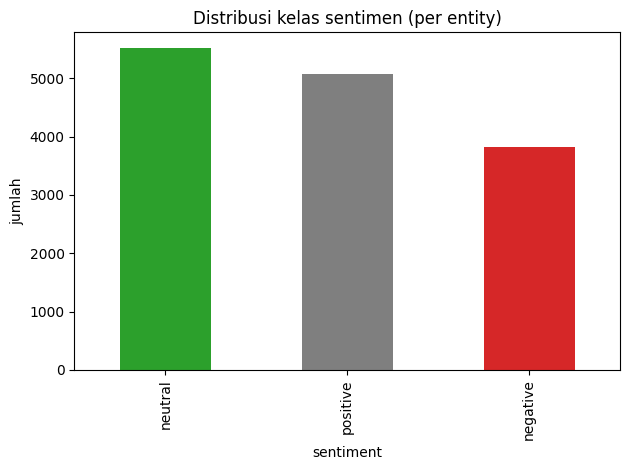

In [7]:
# 4b. Distribusi kelas sentimen (per pasangan entity)
sent_dist = long_df['sentiment'].value_counts()
print('Distribusi sentimen (level entity):')
print(sent_dist)
print('\nProporsi:')
print((sent_dist / len(long_df)).round(3))

ax = sent_dist.plot(kind='bar', color=['#2ca02c','#7f7f7f','#d62728'])
ax.set_title('Distribusi kelas sentimen (per entity)')
ax.set_ylabel('jumlah'); plt.tight_layout(); plt.show()

       title_wordcount  title_charlen
count          10753.0        10753.0
mean               9.9           58.7
std                2.4           14.7
min                3.0           18.0
25%                8.0           49.0
50%               10.0           57.0
75%               11.0           66.0
max               23.0          135.0


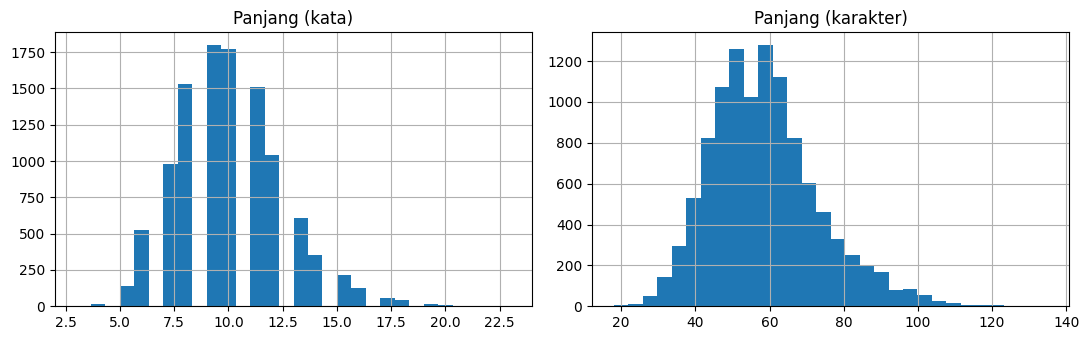

In [8]:
# 4c. Distribusi panjang headline (kata & karakter)
df['title_charlen'] = df['title'].str.len()
print(df[['title_wordcount','title_charlen']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(11,3.5))
df['title_wordcount'].hist(bins=30, ax=axes[0]); axes[0].set_title('Panjang (kata)')
df['title_charlen'].hist(bins=30, ax=axes[1]); axes[1].set_title('Panjang (karakter)')
plt.tight_layout(); plt.show()

## 5. Entity span coverage - kelayakan auto-labeling NER

NER butuh **posisi token** entitas di dalam title (skema BIO). Cara termurah meng-*generate* label NER dari data ini adalah mencocokkan string entity ke title. Tapi itu hanya bisa kalau entity **muncul verbatim** (sama dengan kata aslinya) di title.

Kita ukur: berapa % pasangan (title, entity) di mana `entity` adalah substring dari `title` (case-insensitive)?

- Coverage tinggi (>~95%) -> auto-labeling NER via span-matching layak.
- Coverage rendah -> sebagian entity bersifat *inferred* (mis. "India index", "banking") dan butuh strategi lain. **Ini akan saya laporkan untuk revisi plan.**

In [9]:
def entity_in_title(title, ent):
    return ent.lower() in title.lower()

long_df['exact_substring'] = [entity_in_title(t, e) for t, e in zip(long_df['title'], long_df['entity'])]
cov = long_df['exact_substring'].mean()
print(f'Entity-span coverage (case-insensitive substring): {cov:.1%}')
print(f'Entity yang TIDAK muncul verbatim: {(~long_df["exact_substring"]).sum()} dari {len(long_df)}')

print('\nContoh entity yang tidak match verbatim (kandidat inferred-entity):')
display(long_df[~long_df['exact_substring']][['title','entity','sentiment']].head(15))

Entity-span coverage (case-insensitive substring): 100.0%
Entity yang TIDAK muncul verbatim: 0 dari 14409

Contoh entity yang tidak match verbatim (kandidat inferred-entity):


,title,entity,sentiment


## 6. Kasus conflicting sentiment

Ini inti kesulitan ABSA: satu headline, beberapa entitas, sentimen berbeda (mis. *Gold positive, Silver negative*). Model harus bisa memberi sentimen berbeda untuk title yang sama tergantung entitasnya.

In [10]:
conf = long_df.groupby('s_no').filter(lambda g: g['sentiment'].nunique() > 1)
n_conf_heads = conf['s_no'].nunique()
print(f'Headline dengan sentimen bertentangan antar-entity: {n_conf_heads}')
print('\nContoh:')
for sno, g in list(conf.groupby('s_no'))[:6]:
    title = g['title'].iloc[0]
    pairs = dict(zip(g['entity'], g['sentiment']))
    print(f'  [{sno}] {title}')
    print(f'        -> {pairs}')

Headline dengan sentimen bertentangan antar-entity: 1235

Contoh:
  [9] Gold shines on seasonal demand; Silver dull
        -> {'Gold': 'positive', 'Silver': 'negative'}
  [13] Would stick to banking: Girish Pai, Centrum Broking
        -> {'banking': 'positive', 'Centrum Broking': 'neutral'}
  [14] MSCI adds Aurobindo Pharma to India index
        -> {'Aurobindo Pharma': 'positive', 'MSCI': 'neutral', 'India index': 'neutral'}
  [17] Why Chinese stocks leave US investors vulnerable
        -> {'US': 'negative', 'Chinese stocks': 'neutral'}
  [18] US stocks finish mixed amid more tech selling
        -> {'tech': 'negative', 'US stocks': 'neutral'}
  [19] Opec reduces estimate on oil demand growth
        -> {'oil': 'negative', 'Opec': 'neutral'}


## 7. Simpan output Sprint 1

`sentfin_long.csv` = bentuk kanonik yang dipakai Sprint 2+ (preprocessing -> NER/ABSA format).

In [11]:
out = long_df[['s_no','title','entity','sentiment','exact_substring']].copy()
out_path = DATA_PROCESSED / 'sentfin_long.csv'
out.to_csv(out_path, index=False, encoding='utf-8')
print('Saved:', out_path)
print('Rows :', len(out))
out.head()

Saved: D:\Text Mining Projects\Financial-News-Miner\data\processed\sentfin_long.csv
Rows : 14409


,s_no,title,entity,sentiment,exact_substring
0,1,SpiceJet to issue 6.4 crore warrants to promoters,SpiceJet,neutral,True
1,2,MMTC Q2 net loss at Rs 10.4 crore,MMTC,neutral,True
2,3,"Mid-cap funds can deliver more, stay put: Experts",Mid-cap funds,positive,True
3,4,Mid caps now turn into market darlings,Mid caps,positive,True
4,5,"Market seeing patience, if not conviction: Prakash Diwan",Market,neutral,True


## 8. Ringkasan temuan

- Parse failures:  0 dan nilai sentiment uniknya tidak ada label kotor
- Total headline / total pasangan entity: 10753 (tapi ada duplikat title penuh: 67 -> harus dilihat apakah anotasinya sama atau beda ), dan 14409 setelah long format  / 14409 pasangan (headline, entity)
- Multi-entity headlines:  2850 (cocok dengan klaim 2.800+)
- Distribusi sentimen (level entity): pos: 5075/ neg: 3819 / neu: 5515

    Proporsi: (moderate imbalance)
    
    sentiment
    
    neutral     0.383
    
    positive    0.352
    
    negative    0.265
    
- Entity-span coverage: 100% (all verbatim)
- Conflicting-sentiment headlines: 1235